In [67]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Skipping, found downloaded files in "./animal-faces" (use force=True to force download)


In [68]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cpu


In [69]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
2,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [70]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [71]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

# Augmentasi data dan normalisasi
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [72]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [73]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)

In [74]:
print(train.iloc[2, 0])
train_dataset.__getitem__(2)

/content/animal-faces/afhq/train/wild/pixabay_wild_000874.jpg


(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

In [75]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

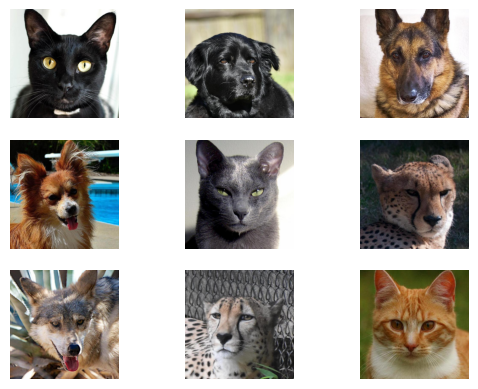

In [76]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [77]:
LR = 5e-5 # Learning rate lebih rendah untuk stabilitas
BATCH_SIZE = 32
EPOCHS = 15

In [78]:
# Memastikan DataLoader menggunakan BATCH_SIZE terbaru
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [79]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()

    self.linear = nn.Linear((128*16*16), 128)
    self.dropout = nn.Dropout(0.5) # Dropout untuk mengurangi overfitting
    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.relu(self.pooling(self.conv1(x)))
    x = self.relu(self.pooling(self.conv2(x)))
    x = self.relu(self.pooling(self.conv3(x)))

    x = self.flatten(x)
    x = self.relu(self.linear(x))
    x = self.dropout(x)
    x = self.output(x)

    return x

In [80]:
model = Net().to(device)

In [81]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
          Dropout-13                  [-1, 128]               0
           Linear-14                   

In [82]:
# Memastikan optimizer menggunakan Learning Rate terbaru
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [83]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

print(f"Memulai pelatihan selama {EPOCHS} epochs...")

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  model.train()
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()
    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  model.eval()
  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()
      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/len(train_loader), 4))
  total_loss_validation_plot.append(round(total_loss_val/len(val_loader), 4))
  total_acc_train_plot.append(round((total_acc_train/len(train_dataset)) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/len(val_dataset)) * 100, 4))

  print(f'Epoch {epoch +1}/{EPOCHS} | Train Loss: {total_loss_train_plot[-1]} | Train Acc: {total_acc_train_plot[-1]}% | Val Loss: {total_loss_validation_plot[-1]} | Val Acc: {total_acc_validation_plot[-1]}%')

Memulai pelatihan selama 15 epochs...
Epoch 1/15 | Train Loss: 0.6833 | Train Acc: 70.7112% | Val Loss: 0.4203 | Val Acc: 84.4215%
Epoch 2/15 | Train Loss: 0.4203 | Train Acc: 84.6426% | Val Loss: 0.3213 | Val Acc: 88.3058%
Epoch 3/15 | Train Loss: 0.3419 | Train Acc: 87.5122% | Val Loss: 0.2677 | Val Acc: 90.4959%
Epoch 4/15 | Train Loss: 0.2844 | Train Acc: 89.6466% | Val Loss: 0.2202 | Val Acc: 91.8595%
Epoch 5/15 | Train Loss: 0.2426 | Train Acc: 91.294% | Val Loss: 0.1864 | Val Acc: 93.0165%
Epoch 6/15 | Train Loss: 0.209 | Train Acc: 92.339% | Val Loss: 0.1891 | Val Acc: 92.686%
Epoch 7/15 | Train Loss: 0.1859 | Train Acc: 93.2867% | Val Loss: 0.139 | Val Acc: 94.9587%
Epoch 8/15 | Train Loss: 0.1664 | Train Acc: 94.0661% | Val Loss: 0.1486 | Val Acc: 94.6694%
Epoch 9/15 | Train Loss: 0.1526 | Train Acc: 94.5089% | Val Loss: 0.1232 | Val Acc: 95.9504%
Epoch 10/15 | Train Loss: 0.1446 | Train Acc: 94.872% | Val Loss: 0.1204 | Val Acc: 95.8678%
Epoch 11/15 | Train Loss: 0.1373 | Tr

In [84]:
model.eval()
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)
    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Final Test Accuracy: {round((total_acc_test/len(test_dataset)) * 100, 4)}%")
print(f"Final Test Loss: {round(total_loss_test/len(test_loader), 4)}")

Final Test Accuracy: 96.5275%
Final Test Loss: 0.097


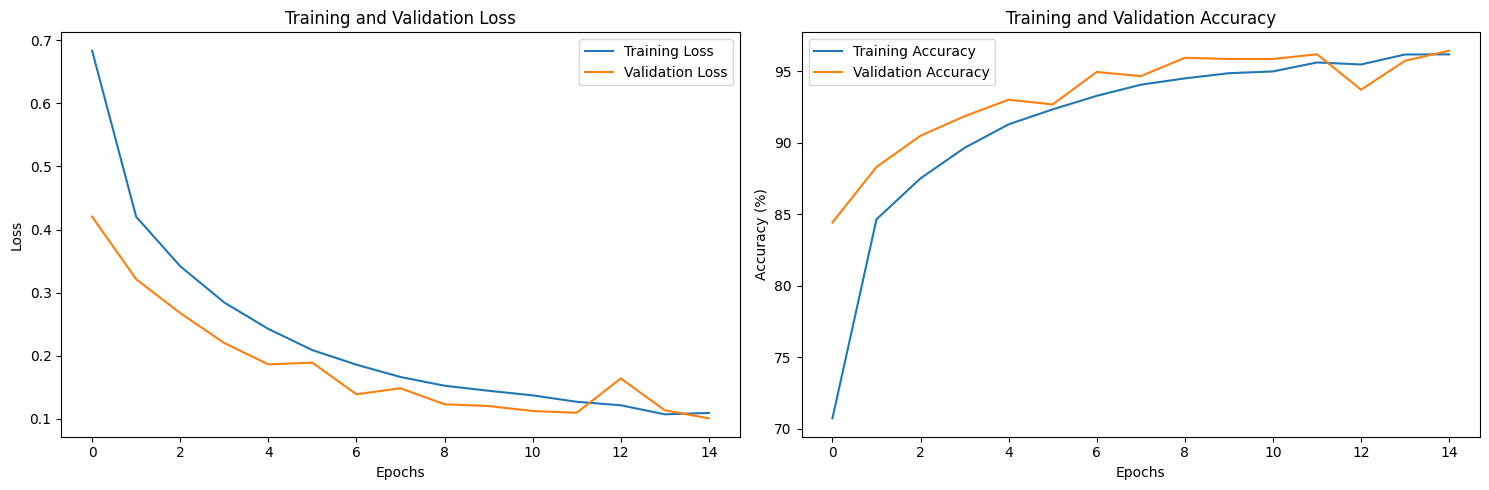

In [85]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()

plt.tight_layout()
plt.show()

In [87]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [88]:
sample_image_path = data_df.sample(n=1)['image_path'].iloc[0]
print(f"Predicting on image: {sample_image_path}")
prediction = predict_image(sample_image_path)
print(f"Predicted label: {prediction[0]}")

Predicting on image: /content/animal-faces/afhq/train/wild/flickr_wild_003692.jpg
Predicted label: wild
